# Model Training & Evaluation

## Objective

The objective of this notebook is to:

- Load the training and testing datasets.
- Apply the preprocessing pipeline developed during feature engineering.
- Train multiple machine learning models.
- Evaluate model performance using classification metrics.
- Compare baseline models and identify top-performing candidates for hyperparameter tuning.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.pipeline import Pipeline

## Load Training and Testing Data

In [2]:
train_df = pd.read_csv('../artifacts/train.csv')
test_df = pd.read_csv('../artifacts/test.csv')

print(train_df.shape)
print(test_df.shape)

(1719, 33)
(430, 33)


## Load Preprocessing Pipeline

In [3]:
preprocessor = joblib.load(
    '../artifacts/preprocessor.pkl'
)

In [4]:
X_train = train_df.drop('Diagnosis', axis=1)
y_train = train_df['Diagnosis']

X_test = test_df.drop('Diagnosis', axis=1)
y_test = test_df['Diagnosis']

## Apply Data Transformations

In [5]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(1719, 38)
(430, 38)


## Baseline Model Selection

To establish a performance benchmark, multiple machine learning algorithms are trained and evaluated using the transformed dataset.

The following models are selected:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Classifier (SVC)
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- CatBoost
- LightGBM

Performance will be compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [6]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(),

    "SVC":
        SVC(probability=True),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        ),

    "CatBoost":
        CatBoostClassifier(
            random_state=42,
            verbose=0
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42,
            verbose=-1
        )
}

## Baseline Model Training and Evaluation

Each baseline model is trained on the processed training dataset and evaluated on the test dataset.

The objective is to identify the strongest candidate models for further experimentation and hyperparameter tuning.

In [7]:
results = []

for name, model in models.items():

    model.fit(
        X_train_processed,
        y_train
    )

    y_pred = model.predict(
        X_test_processed
    )

    y_prob = model.predict_proba(
        X_test_processed
    )[:,1]

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

        "Precision":
            precision_score(
                y_test,
                y_pred
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred
            ),

        "F1 Score":
            f1_score(
                y_test,
                y_pred
            ),

        "ROC-AUC":
            roc_auc_score(
                y_test,
                y_prob
            )
    })

In [9]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
9,LightGBM,0.953488,0.945946,0.921053,0.933333,0.951936
6,Gradient Boosting,0.944186,0.921053,0.921053,0.921053,0.947321
7,XGBoost,0.941860,0.931973,0.901316,0.916388,0.945239
8,CatBoost,0.948837,0.933333,0.921053,0.927152,0.943156
5,AdaBoost,0.918605,0.872611,0.901316,0.886731,0.938399
4,Random Forest,0.939535,0.943662,0.881579,0.911565,0.936423
2,SVC,0.853488,0.844961,0.717105,0.775801,0.904085
0,Logistic Regression,0.816279,0.744966,0.730263,0.737542,0.886478
3,Decision Tree,0.876744,0.807453,0.855263,0.830671,0.871876
1,KNN,0.760465,0.720721,0.526316,0.608365,0.761253


### Observation

- Ensemble-based algorithms significantly outperform traditional machine learning models.
- LightGBM achieved the highest ROC-AUC score (95.19%) among all baseline models.
- Gradient Boosting, XGBoost, and CatBoost also demonstrated strong predictive performance.
- KNN and Logistic Regression produced the weakest results and will not be considered for further optimization.
- The top-performing boosting models will be selected for detailed evaluation.

## Detailed Model Evaluation Framework

To better understand model behaviour, additional evaluation methods are implemented:

- Classification Report
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

These metrics provide deeper insights beyond overall accuracy.

In [10]:
# Prints key classification metrics in a clean format.



def classification_report_print(y_true, y_pred, model_name="Model"):
    """
    Prints key classification metrics in a clean format.

    Parameters:
    - y_true: Actual labels
    - y_pred: Predicted labels
    - model_name: Name of the model (optional)
    """

    print(f"=== {model_name} Performance Metrics ===")
    print(f"Accuracy      : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision     : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall        : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score      : {f1_score(y_true, y_pred):.4f}")

# Plots a clean confusion matrix heatmap.
def confusion_matrix_print(y_true, y_pred, model_name="Model"):
    """
    Plots a clean confusion matrix heatmap.

    Parameters:
    - y_true: Actual labels
    - y_pred: Predicted labels
    - model_name: Name of the model (optional)
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", linewidths=0.5)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plots the ROC curve and prints the AUC score.
def plot_roc_curve(y_true, y_proba, model_name="Model"):
    """
    Plots the ROC curve and prints the AUC score.

    Parameters:
    - y_true: Actual labels (0/1)
    - y_proba: Predicted probabilities for the positive class
    - model_name: Name of the model (string)
    """

    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc:.3f}", linewidth=2)
    plt.plot([0,1], [0,1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Plots the Precision–Recall curve and prints the Average Precision (AP) score.
def plot_precision_recall_curve(y_true, y_proba, model_name="Model"):
    """
    Plots the Precision–Recall curve and prints the Average Precision (AP) score.

    Parameters:
    - y_true: Actual labels (0/1)
    - y_proba: Predicted probabilities for the positive class
    - model_name: Name of the model (string)
    """

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=f"{model_name} AP = {ap:.3f}", linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def run_pipeline(model, preprocessor, X_train, X_test, y_train):
    """
    Fits a pipeline for ANY model and returns predictions + probabilities.
    """

    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    return pipe, y_pred, y_proba





# LightGBM Evaluation

LightGBM achieved the highest ROC-AUC score during baseline comparison and is therefore selected for detailed evaluation.

The model is assessed using multiple classification metrics and visual diagnostic plots.

In [11]:
lgbm_pipeline,lgbm_pred,lgbm_proba = run_pipeline(LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [12]:
classification_report_print(y_true=y_test,y_pred=lgbm_pred,model_name="LGBM")

=== LGBM Performance Metrics ===
Accuracy      : 0.9535
Precision     : 0.9459
Recall        : 0.9211
F1 Score      : 0.9333


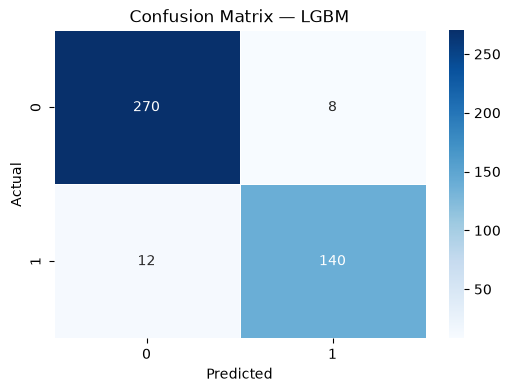

In [13]:
confusion_matrix_print(y_true=y_test,y_pred=lgbm_pred,model_name="LGBM")

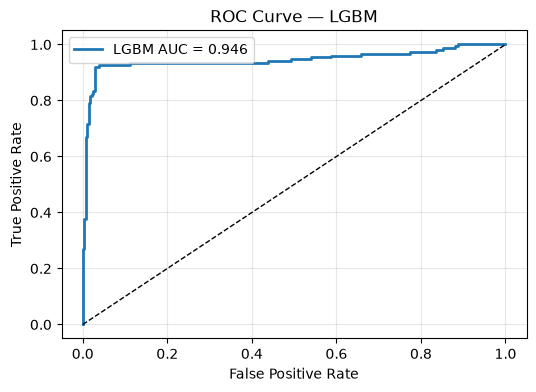

In [14]:
plot_roc_curve(y_true=y_test,y_proba=lgbm_proba,model_name="LGBM")

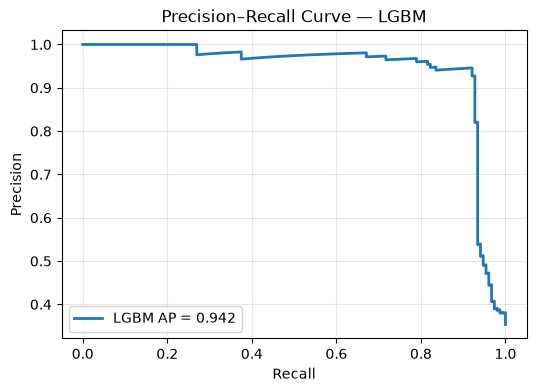

In [15]:
plot_precision_recall_curve(y_true=y_test,y_proba=lgbm_proba,model_name="LGBM")

### Observation

- LightGBM demonstrates excellent classification performance.
- Both recall and precision remain above 92%.
- ROC and Precision-Recall curves indicate strong class separation.
- The model appears highly effective for Alzheimer's disease prediction and will be considered for hyperparameter tuning.

# XGBoost Evaluation

XGBoost is one of the strongest gradient boosting algorithms and delivered highly competitive results during baseline testing.

A detailed evaluation is performed to compare its performance against LightGBM.

In [16]:
xgb_pipeline,xgb_pred,xgb_proba = run_pipeline(XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [17]:
classification_report_print(y_true=y_test,y_pred=xgb_pred,model_name="X GradientBoost")

=== X GradientBoost Performance Metrics ===
Accuracy      : 0.9442
Precision     : 0.9324
Recall        : 0.9079
F1 Score      : 0.9200


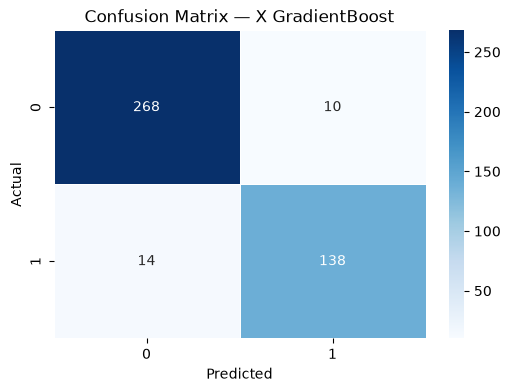

In [18]:
confusion_matrix_print(y_true=y_test,y_pred=xgb_pred,model_name="X GradientBoost")

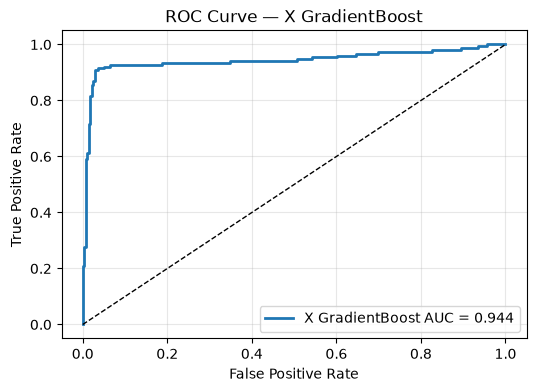

In [19]:
plot_roc_curve(y_true=y_test,y_proba=xgb_proba,model_name="X GradientBoost")

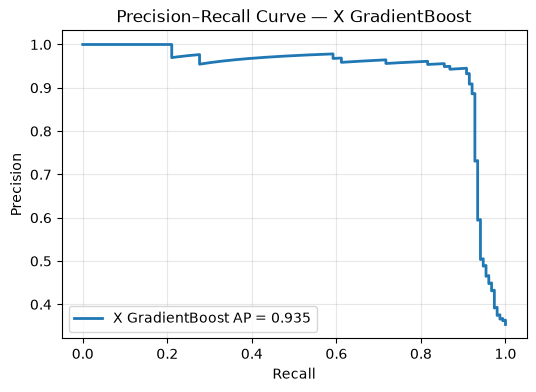

In [20]:
plot_precision_recall_curve(y_true=y_test,y_proba=xgb_proba,model_name="X GradientBoost")

### Observation

- XGBoost achieved strong predictive performance with high recall and ROC-AUC.
- Performance is comparable to LightGBM.
- The model successfully identifies Alzheimer's patients while maintaining low false positive rates.
- XGBoost remains a strong candidate for further optimization.

# Gradient Boosting Evaluation

Gradient Boosting demonstrated strong baseline performance and is evaluated further to determine whether it can compete with modern boosting frameworks.

In [21]:
gb_pipeline,gb_pred,gb_proba = run_pipeline(GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [22]:
classification_report_print(y_true=y_test,y_pred=gb_pred,model_name="GradientBoost")

=== GradientBoost Performance Metrics ===
Accuracy      : 0.9372
Precision     : 0.9085
Recall        : 0.9145
F1 Score      : 0.9115


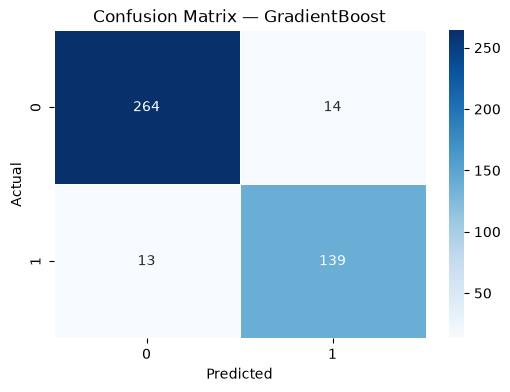

In [23]:
confusion_matrix_print(y_true=y_test,y_pred=gb_pred,model_name="GradientBoost")

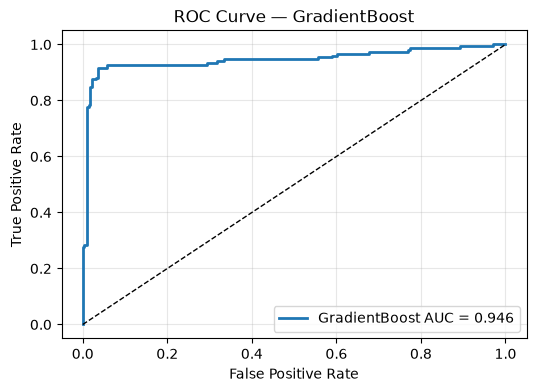

In [24]:
plot_roc_curve(y_true=y_test,y_proba=gb_proba,model_name="GradientBoost")

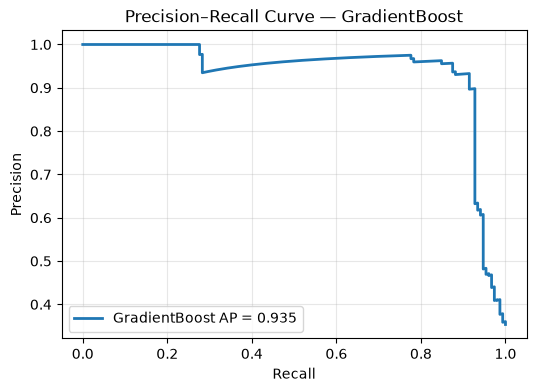

In [25]:
plot_precision_recall_curve(y_true=y_test,y_proba=gb_proba,model_name="GradientBoost")

### Observation

- Gradient Boosting achieved excellent recall and F1-score performance.
- The model produced balanced predictions across both classes.
- Performance remains slightly below LightGBM but still exceeds most traditional machine learning algorithms.

# CatBoost Evaluation

CatBoost is designed to handle structured tabular datasets effectively and often performs well on classification problems involving categorical information.

The model is evaluated using the same framework for comparison.

In [26]:
cat_pipeline, cat_pred, cat_proba = run_pipeline(
    CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        random_state=42,
        verbose=0
    ),
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train
)



In [27]:
classification_report_print(
    y_true=y_test,
    y_pred=cat_pred,
    model_name="CatBoost"
)



=== CatBoost Performance Metrics ===
Accuracy      : 0.9465
Precision     : 0.9329
Recall        : 0.9145
F1 Score      : 0.9236


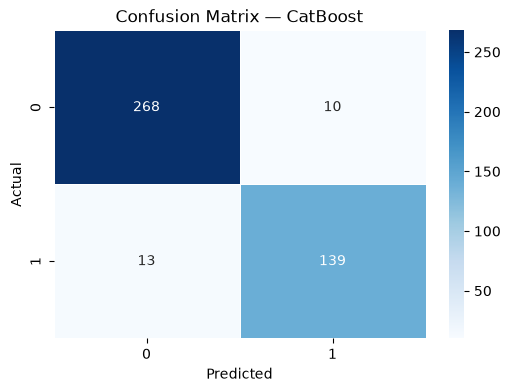

In [29]:

confusion_matrix_print(
    y_true=y_test,
    y_pred=cat_pred,
    model_name="CatBoost"
)


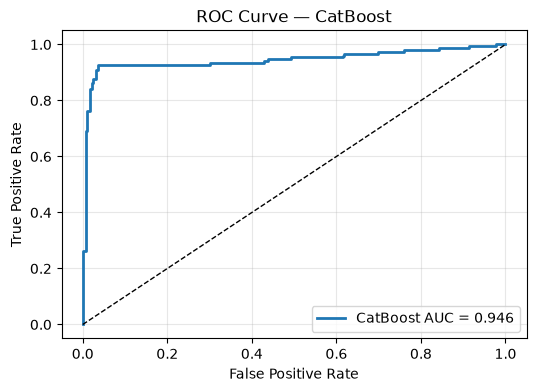

In [30]:


plot_roc_curve(
    y_true=y_test,
    y_proba=cat_proba,
    model_name="CatBoost"
)



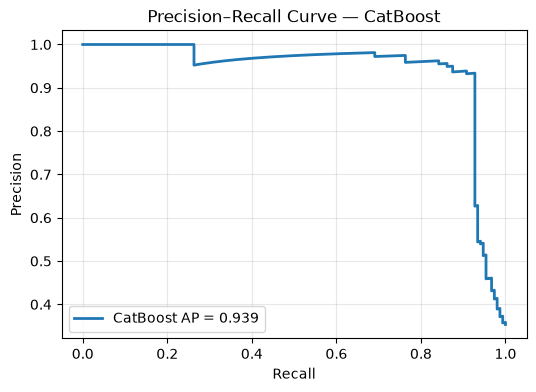

In [31]:
plot_precision_recall_curve(
    y_true=y_test,
    y_proba=cat_proba,
    model_name="CatBoost"
)

### Observation

- CatBoost delivered highly competitive results with strong recall and ROC-AUC scores.
- Performance is comparable to both LightGBM and XGBoost.
- The model demonstrates excellent capability in identifying Alzheimer's disease cases.

## Final Model Comparison

The detailed evaluation results from the selected top-performing models are consolidated into a final comparison table.

This comparison will guide the selection of models for hyperparameter tuning.

In [32]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

In [33]:
results.append(evaluate_model("Gradient Boosting-Tuned", y_test, gb_pred, gb_proba))
results.append(evaluate_model("XGBoost-Tuned", y_test, xgb_pred, xgb_proba))
results.append(evaluate_model("LightGBM-Tuned", y_test, lgbm_pred, lgbm_proba))
results.append(evaluate_model("CatBoost-Tuned", y_test, cat_pred, cat_proba))

In [34]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
9,LightGBM,0.953488,0.945946,0.921053,0.933333,0.951936
6,Gradient Boosting,0.944186,0.921053,0.921053,0.921053,0.947321
10,Gradient Boosting-Tuned,0.937209,0.908497,0.914474,0.911475,0.946067
12,LightGBM-Tuned,0.953488,0.945946,0.921053,0.933333,0.945854
13,CatBoost-Tuned,0.946512,0.932886,0.914474,0.923588,0.945570
7,XGBoost,0.941860,0.931973,0.901316,0.916388,0.945239
11,XGBoost-Tuned,0.944186,0.932432,0.907895,0.920000,0.943653
8,CatBoost,0.948837,0.933333,0.921053,0.927152,0.943156
5,AdaBoost,0.918605,0.872611,0.901316,0.886731,0.938399
4,Random Forest,0.939535,0.943662,0.881579,0.911565,0.936423


### Final Observation

- LightGBM achieved the highest overall ROC-AUC score and demonstrated the strongest balance between precision and recall.
- XGBoost and CatBoost produced competitive results and remain suitable alternatives.
- Gradient Boosting performed well but was slightly less effective than LightGBM.
- LightGBM, XGBoost, and CatBoost are selected for the hyperparameter tuning phase.

## Save Model Comparison Results

The final comparison results are saved as an artifact for future reference and model selection.

In [35]:
results_df.to_csv(
    "../artifacts/model_comparison.csv",
    index=False
)

# Model Training Summary

## Key Findings

1. Ten baseline classification models were evaluated.
2. Ensemble boosting algorithms significantly outperformed traditional machine learning models.
3. LightGBM achieved the strongest overall performance.
4. XGBoost and CatBoost also demonstrated excellent predictive capability.
5. The top three models have been selected for hyperparameter tuning.
6. Final model selection will be performed after tuning and cross-validation.

## Next Steps

- Hyperparameter Tuning
- Cross Validation
- Threshold Optimization
- Final Model Selection
- Model Serialization